In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn_extra.cluster import KMedoids

In [124]:
df = pd.read_csv(
    "dataset/tourism_indonesia_2016-2026_clean.csv"
)

print("Shape:", df.shape)

df.head()

Shape: (4620, 7)


,Pintu Masuk,Bulan,Jumlah,Jenis Data,Tahun,Bulan_Num,Tanggal
0,A. Pintu Udara,Januari,548863.0,Sub-Total,2016,1,2016-01-01
1,Ngurah Rai,Januari,343663.0,Pintu Masuk,2016,1,2016-01-01
2,Soekarno-Hatta,Januari,153503.0,Pintu Masuk,2016,1,2016-01-01
3,Juanda,Januari,11674.0,Pintu Masuk,2016,1,2016-01-01
4,Kualanamu,Januari,10080.0,Pintu Masuk,2016,1,2016-01-01


In [125]:
print("Missing:")
print(df.isnull().sum())

print("\nDuplicate key:")
print(
    df.duplicated(
        subset=["Pintu Masuk", "Tahun", "Bulan"]
    ).sum()
)

Missing:
Pintu Masuk      0
Bulan            0
Jumlah         438
Jenis Data       0
Tahun            0
Bulan_Num        0
Tanggal          0
dtype: int64

Duplicate key:
0


# Validasi Input

In [126]:
print("\nShape:")
print(df.shape)

print("\nTipe data:")
print(df.dtypes)

print("\nMissing value:")
print(df.isnull().sum())

print("\nDuplicate key:")
print(
    df.duplicated(
        subset=["Pintu Masuk", "Tahun", "Bulan"]
    ).sum()
)

print("\nTahun:")
print(
    df["Tahun"]
    .value_counts()
    .sort_index()
)


Shape:
(4620, 7)

Tipe data:
Pintu Masuk     object
Bulan           object
Jumlah         float64
Jenis Data      object
Tahun            int64
Bulan_Num        int64
Tanggal         object
dtype: object

Missing value:
Pintu Masuk      0
Bulan            0
Jumlah         438
Jenis Data       0
Tahun            0
Bulan_Num        0
Tanggal          0
dtype: int64

Duplicate key:
0

Tahun:
Tahun
2016    420
2017    420
2018    420
2019    420
2020    420
2021    420
2022    420
2023    420
2024    420
2025    420
2026    420
Name: count, dtype: int64


# klasifikasi cluster base

In [127]:
cluster_base = df[
    (df["Jenis Data"] == "Pintu Masuk") &
    (df["Tahun"].between(2016, 2019))
].copy()

print("Shape cluster_base:", cluster_base.shape)

print(
    "Jumlah pintu masuk:",
    cluster_base["Pintu Masuk"].nunique()
)

print(
    "Tahun:",
    sorted(cluster_base["Tahun"].unique())
)

Shape cluster_base: (1248, 7)
Jumlah pintu masuk: 26
Tahun: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]


In [128]:
monthly_profile = (
    cluster_base
    .groupby(
        ["Pintu Masuk", "Bulan_Num"]
    )["Jumlah"]
    .mean()
    .unstack()
)

monthly_profile.columns = [
    "Jan_Avg",
    "Feb_Avg",
    "Mar_Avg",
    "Apr_Avg",
    "May_Avg",
    "Jun_Avg",
    "Jul_Avg",
    "Aug_Avg",
    "Sep_Avg",
    "Oct_Avg",
    "Nov_Avg",
    "Dec_Avg"
]

print("Shape:", monthly_profile.shape)

display(monthly_profile.head())

Shape: (26, 12)


,Jan_Avg,Feb_Avg,Mar_Avg,Apr_Avg,May_Avg,Jun_Avg,Jul_Avg,Aug_Avg,Sep_Avg,Oct_Avg,Nov_Avg,Dec_Avg
Pintu Masuk,,,,,,,,,,,,
Adi Sucipto,8627.750000,9767.000000,10804.250000,10451.000000,9693.750000,7135.500000,12370.000000,13246.250000,11923.000000,11487.500000,10467.250000,11422.000000
Ahmad Yani,1797.666667,1703.666667,2043.666667,1838.000000,1499.666667,1686.666667,2086.333333,2436.666667,2050.333333,2108.666667,2167.000000,2303.666667
Aruk,531.666667,1142.666667,1123.333333,654.000000,809.333333,1913.666667,991.000000,1470.333333,1003.666667,792.666667,961.333333,1584.000000
Atambua,5725.333333,4596.333333,5253.000000,7010.666667,5278.666667,7334.333333,6981.666667,7841.333333,7587.000000,7802.333333,8002.333333,11185.666667
Bandara Int. Lombok,5667.000000,6087.250000,8027.250000,8599.500000,7455.500000,7159.750000,10351.750000,8066.000000,7301.500000,7199.000000,5614.500000,6395.000000


In [129]:
month_cols = [
    "Jan_Avg",
    "Feb_Avg",
    "Mar_Avg",
    "Apr_Avg",
    "May_Avg",
    "Jun_Avg",
    "Jul_Avg",
    "Aug_Avg",
    "Sep_Avg",
    "Oct_Avg",
    "Nov_Avg",
    "Dec_Avg"
]

mean_volume = monthly_profile.mean(axis=1)

seasonal_profile = monthly_profile.div(
    mean_volume,
    axis=0
)

seasonal_profile.columns = [
    "Jan_Index",
    "Feb_Index",
    "Mar_Index",
    "Apr_Index",
    "May_Index",
    "Jun_Index",
    "Jul_Index",
    "Aug_Index",
    "Sep_Index",
    "Oct_Index",
    "Nov_Index",
    "Dec_Index"
]

display(seasonal_profile.head())

,Jan_Index,Feb_Index,Mar_Index,Apr_Index,May_Index,Jun_Index,Jul_Index,Aug_Index,Sep_Index,Oct_Index,Nov_Index,Dec_Index
Pintu Masuk,,,,,,,,,,,,
Adi Sucipto,0.812691,0.920003,1.017707,0.984432,0.913103,0.672129,1.165193,1.247731,1.123087,1.082065,0.985963,1.075896
Ahmad Yani,0.909367,0.861816,1.033808,0.929770,0.758621,0.853216,1.055392,1.232611,1.037181,1.066689,1.096198,1.165332
Aruk,0.491614,1.056584,1.038708,0.604731,0.748363,1.769501,0.916343,1.359566,0.928056,0.732951,0.888912,1.464670
Atambua,0.812117,0.651972,0.745118,0.994436,0.748759,1.040347,0.990323,1.112263,1.076187,1.106731,1.135101,1.586644
Bandara Int. Lombok,0.773441,0.830797,1.095571,1.173673,1.017538,0.977173,1.412822,1.100860,0.996520,0.982530,0.766275,0.872799


In [130]:
feature_volume = np.log1p(mean_volume)

feature_volume.name = "Log_Mean_Volume"

recovery_base = df[
    (df["Jenis Data"] == "Pintu Masuk") &
    (df["Tahun"].isin([2019, 2025]))
].copy()

recovery_total = (
    recovery_base
    .groupby(["Pintu Masuk", "Tahun"])["Jumlah"]
    .sum(min_count=1)
    .unstack()
)

recovery_total.columns = [
    "Baseline_2019",
    "Value_2025"
]

recovery_total["Recovery_2025"] = (
    recovery_total["Value_2025"]
    / recovery_total["Baseline_2019"]
) * 100

In [131]:
cluster_features = seasonal_profile.copy()

cluster_features["Log_Mean_Volume"] = feature_volume

cluster_features["Recovery_2025"] = (
    recovery_total["Recovery_2025"]
)

print("Shape:", cluster_features.shape)

display(cluster_features.head())

print("\nMissing:")
print(cluster_features.isnull().sum())

print("\nValidasi Isi fityr :")
print(cluster_features.describe().T)

Shape: (26, 14)


,Jan_Index,Feb_Index,Mar_Index,Apr_Index,May_Index,Jun_Index,Jul_Index,Aug_Index,Sep_Index,Oct_Index,Nov_Index,Dec_Index,Log_Mean_Volume,Recovery_2025
Pintu Masuk,,,,,,,,,,,,,,
Adi Sucipto,0.812691,0.920003,1.017707,0.984432,0.913103,0.672129,1.165193,1.247731,1.123087,1.082065,0.985963,1.075896,9.270237,90.965955
Ahmad Yani,0.909367,0.861816,1.033808,0.929770,0.758621,0.853216,1.055392,1.232611,1.037181,1.066689,1.096198,1.165332,7.589757,25.049005
Aruk,0.491614,1.056584,1.038708,0.604731,0.748363,1.769501,0.916343,1.359566,0.928056,0.732951,0.888912,1.464670,6.987003,248.297795
Atambua,0.812117,0.651972,0.745118,0.994436,0.748759,1.040347,0.990323,1.112263,1.076187,1.106731,1.135101,1.586644,8.860909,205.115250
Bandara Int. Lombok,0.773441,0.830797,1.095571,1.173673,1.017538,0.977173,1.412822,1.100860,0.996520,0.982530,0.766275,0.872799,8.899458,163.902498



Missing:
Jan_Index          0
Feb_Index          0
Mar_Index          0
Apr_Index          0
May_Index          0
Jun_Index          0
Jul_Index          0
Aug_Index          0
Sep_Index          0
Oct_Index          0
Nov_Index          0
Dec_Index          0
Log_Mean_Volume    0
Recovery_2025      0
dtype: int64

Validasi Isi fityr :
                 count        mean        std       min        25%        50%  \
Jan_Index         26.0    0.887383   0.288634  0.491614   0.779328   0.821872   
Feb_Index         26.0    0.993166   0.313841  0.651972   0.863999   0.914803   
Mar_Index         26.0    1.104876   0.346466  0.745118   0.985580   1.036258   
Apr_Index         26.0    0.928448   0.175796  0.494574   0.840311   0.955214   
May_Index         26.0    0.848999   0.163239  0.280811   0.751224   0.865563   
Jun_Index         26.0    0.923718   0.281619  0.192212   0.804839   0.932732   
Jul_Index         26.0    0.971333   0.289704  0.026720   0.907037   0.994424   
Aug_Index    

# standar scaller

In [132]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    cluster_features
)

X_scaled_df = pd.DataFrame(
    X_scaled,
    index=cluster_features.index,
    columns=cluster_features.columns
)

print("Mean:")
print(X_scaled_df.mean().round(6))

print("\nStd:")
print(X_scaled_df.std(ddof=0).round(6))

Mean:
Jan_Index          0.0
Feb_Index          0.0
Mar_Index          0.0
Apr_Index          0.0
May_Index          0.0
Jun_Index          0.0
Jul_Index          0.0
Aug_Index         -0.0
Sep_Index         -0.0
Oct_Index         -0.0
Nov_Index         -0.0
Dec_Index          0.0
Log_Mean_Volume    0.0
Recovery_2025      0.0
dtype: float64

Std:
Jan_Index          1.0
Feb_Index          1.0
Mar_Index          1.0
Apr_Index          1.0
May_Index          1.0
Jun_Index          1.0
Jul_Index          1.0
Aug_Index          1.0
Sep_Index          1.0
Oct_Index          1.0
Nov_Index          1.0
Dec_Index          1.0
Log_Mean_Volume    1.0
Recovery_2025      1.0
dtype: float64


In [133]:
# kandidat K

k_results = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    k_results.append({
        "k": k,
        "Silhouette": silhouette_score(
            X_scaled,
            labels
        ),
        "Davies_Bouldin": davies_bouldin_score(
            X_scaled,
            labels
        ),
        "Calinski_Harabasz": calinski_harabasz_score(
            X_scaled,
            labels
        ),
        "Inertia": model.inertia_
    })

k_results = pd.DataFrame(k_results)

display(
    k_results.round(4)
)

,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inertia
0,2,0.6295,0.7270,19.5933,200.3976
1,3,0.3448,0.9654,14.9144,158.4742
2,4,0.3328,0.6569,15.0658,119.1713
3,5,0.1214,1.1481,13.5111,101.8596
4,6,0.1398,1.0380,13.1230,85.0316


# Algoritma K-Means Clustering

In [134]:
kmeans_results = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    kmeans_results.append({
        "k": k,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies_Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_scaled, labels),
        "Inertia": model.inertia_
    })

kmeans_results = pd.DataFrame(kmeans_results)

print("Hasil K-Means:")
display(kmeans_results.round(4))

Hasil K-Means:


,k,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inertia
0,2,0.6295,0.7270,19.5933,200.3976
1,3,0.3448,0.9654,14.9144,158.4742
2,4,0.3328,0.6569,15.0658,119.1713
3,5,0.1214,1.1481,13.5111,101.8596
4,6,0.1398,1.0380,13.1230,85.0316


# pilih konfigurasi terbaik K-Means

In [135]:
best_kmeans_row = kmeans_results.loc[
    kmeans_results["Silhouette"].idxmax()
]

best_kmeans_k = int(best_kmeans_row["k"])

print("Best K-Means k:", best_kmeans_k)
print(best_kmeans_row.round(4))

Best K-Means k: 2
k                      2.0000
Silhouette             0.6295
Davies_Bouldin         0.7270
Calinski_Harabasz     19.5933
Inertia              200.3976
Name: 0, dtype: float64


# Fit K-Means terbaik

In [136]:
kmeans_best = KMeans(
    n_clusters=best_kmeans_k,
    random_state=42,
    n_init=20
)

labels_kmeans = kmeans_best.fit_predict(X_scaled)

print(
    pd.Series(labels_kmeans)
    .value_counts()
    .sort_index()
)

0     2
1    24
Name: count, dtype: int64


# mengHubungkan cluster dengan nama pintu masuk

In [137]:
kmeans_result = pd.DataFrame({
    "Pintu Masuk": cluster_features.index,
    "Cluster": labels_kmeans
})

kmeans_result = kmeans_result.sort_values(
    ["Cluster", "Pintu Masuk"]
)

display(kmeans_result)

,Pintu Masuk,Cluster
22,Tanjung Benoa,0
23,Tanjung Mas,0
0,Adi Sucipto,1
1,Ahmad Yani,1
2,Aruk,1
3,Atambua,1
4,Bandara Int. Lombok,1
5,Batam,1
6,Entikong,1
7,Hasanuddin,1


# visualisasi pca

Explained variance ratio: [0.48793404 0.15251738]
Total explained variance: 0.6404514170069442


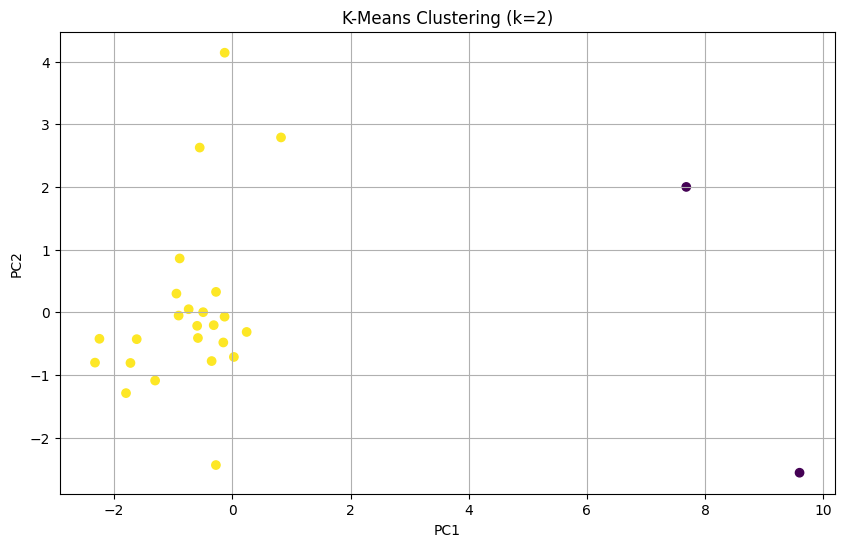

In [138]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_kmeans
)

plt.title(
    f"K-Means Clustering (k={best_kmeans_k})"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.grid(True)
plt.show()

# interpretasi K-Means.

In [139]:
cluster_profile = cluster_features.copy()

cluster_profile["Cluster"] = labels_kmeans

cluster_summary = (
    cluster_profile
    .groupby("Cluster")
    .mean()
)

display(
    cluster_summary.round(3)
)

,Jan_Index,Feb_Index,Mar_Index,Apr_Index,May_Index,Jun_Index,Jul_Index,Aug_Index,Sep_Index,Oct_Index,Nov_Index,Dec_Index,Log_Mean_Volume,Recovery_2025
Cluster,,,,,,,,,,,,,,
0,1.584,2.002,2.188,0.622,0.492,0.396,0.120,0.431,0.405,0.622,1.557,1.581,7.674,60.568
1,0.829,0.909,1.015,0.954,0.879,0.968,1.042,1.161,1.031,0.995,0.989,1.228,8.977,108.917


In [140]:
summary_key = (
    cluster_profile
    .groupby("Cluster")[
        ["Log_Mean_Volume", "Recovery_2025"]
    ]
    .mean()
)

display(
    summary_key.round(2)
)

for cluster in sorted(
    cluster_profile["Cluster"].unique()
):
    
    print(f"\nCLUSTER {cluster}")
    
    print(
        cluster_profile[
            cluster_profile["Cluster"] == cluster
        ].index.tolist()
    )

,Log_Mean_Volume,Recovery_2025
Cluster,,
0,7.67,60.57
1,8.98,108.92



CLUSTER 0
['Tanjung Benoa', 'Tanjung Mas']

CLUSTER 1
['Adi Sucipto', 'Ahmad Yani', 'Aruk', 'Atambua', 'Bandara Int. Lombok', 'Batam', 'Entikong', 'Hasanuddin', 'Husein Sastranegara', 'Jayapura', 'Juanda', 'Kualanamu', 'Minangkabau', 'Nanga Badau', 'Ngurah Rai', 'Sam Ratulangi', 'Soekarno-Hatta', 'Sultan Badaruddin II', 'Sultan Iskandar Muda', 'Sultan Syarif Kasim II', 'Supadio', 'Tanjung Balai Karimun', 'Tanjung Pinang', 'Tanjung Uban']


In [141]:
seasonal_cluster = (
    cluster_profile
    .groupby("Cluster")[[
        "Jan_Index",
        "Feb_Index",
        "Mar_Index",
        "Apr_Index",
        "May_Index",
        "Jun_Index",
        "Jul_Index",
        "Aug_Index",
        "Sep_Index",
        "Oct_Index",
        "Nov_Index",
        "Dec_Index"
    ]]
    .mean()
)

display(
    seasonal_cluster.round(2)
)

,Jan_Index,Feb_Index,Mar_Index,Apr_Index,May_Index,Jun_Index,Jul_Index,Aug_Index,Sep_Index,Oct_Index,Nov_Index,Dec_Index
Cluster,,,,,,,,,,,,
0,1.58,2.00,2.19,0.62,0.49,0.40,0.12,0.43,0.40,0.62,1.56,1.58
1,0.83,0.91,1.01,0.95,0.88,0.97,1.04,1.16,1.03,0.99,0.99,1.23


# ALGORITMA K-MEDOIDS

In [142]:
kmedoids_results = []

for k in range(2, 7):

    model = KMedoids(
        n_clusters=k,
        random_state=42,
        metric="euclidean",
        method="alternate"
    )

    labels = model.fit_predict(X_scaled)

    kmedoids_results.append({
        "k": k,
        "Silhouette": silhouette_score(
            X_scaled,
            labels
        ),
        "Davies_Bouldin": davies_bouldin_score(
            X_scaled,
            labels
        ),
        "Calinski_Harabasz": calinski_harabasz_score(
            X_scaled,
            labels
        )
    })

kmedoids_results = pd.DataFrame(
    kmedoids_results
)

display(
    kmedoids_results.round(4)
)

,k,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,0.1448,2.0821,4.2643
1,3,0.0121,2.2001,2.7242
2,4,0.0334,1.7543,3.6185
3,5,-0.0433,1.7714,2.8416
4,6,-0.0494,1.6386,2.8874


In [143]:
# PILIH K-MEDOIDS TERBAIK
best_kmedoids_row = kmedoids_results.loc[
    kmedoids_results["Silhouette"].idxmax()
]

best_kmedoids_k = int(
    best_kmedoids_row["k"]
)

print(
    "Best K-Medoids k:",
    best_kmedoids_k
)

print(
    best_kmedoids_row.round(4)
)

Best K-Medoids k: 2
k                    2.0000
Silhouette           0.1448
Davies_Bouldin       2.0821
Calinski_Harabasz    4.2643
Name: 0, dtype: float64


In [144]:
# FIT K-MEDOIDS TERBIAK

kmedoids_best = KMedoids(
    n_clusters=best_kmedoids_k,
    random_state=42,
    metric="euclidean",
    method="alternate"
)

labels_kmedoids = kmedoids_best.fit_predict(
    X_scaled
)

print(
    pd.Series(labels_kmedoids)
    .value_counts()
    .sort_index()
)

0    15
1    11
Name: count, dtype: int64


In [145]:
# CEK ANGGOTA CLUSTER

kmedoids_result = pd.DataFrame({
    "Pintu Masuk": cluster_features.index,
    "Cluster": labels_kmedoids
})

display(
    kmedoids_result.sort_values(
        ["Cluster", "Pintu Masuk"]
    )
)

,Pintu Masuk,Cluster
0,Adi Sucipto,0
3,Atambua,0
4,Bandara Int. Lombok,0
5,Batam,0
8,Husein Sastranegara,0
9,Jayapura,0
10,Juanda,0
11,Kualanamu,0
12,Minangkabau,0
14,Ngurah Rai,0


In [146]:
# HITUNG METRIK FINAL K-MEDOIDS

kmedoids_best_metrics = {
    "Algoritma": "K-Medoids",
    "Parameter": f"k={best_kmedoids_k}",
    "Silhouette": silhouette_score(
        X_scaled,
        labels_kmedoids
    ),
    "Davies_Bouldin": davies_bouldin_score(
        X_scaled,
        labels_kmedoids
    ),
    "Calinski_Harabasz": calinski_harabasz_score(
        X_scaled,
        labels_kmedoids
    )
}

print(kmedoids_best_metrics)

{'Algoritma': 'K-Medoids', 'Parameter': 'k=2', 'Silhouette': 0.14483019217742493, 'Davies_Bouldin': 2.0821482649650607, 'Calinski_Harabasz': 4.264327288166607}


# Algoritma Agglomerative Clustering

In [147]:
agglo_results = []

for k in range(2, 7):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = model.fit_predict(X_scaled)

    agglo_results.append({
        "k": k,
        "Silhouette": silhouette_score(
            X_scaled,
            labels
        ),
        "Davies_Bouldin": davies_bouldin_score(
            X_scaled,
            labels
        ),
        "Calinski_Harabasz": calinski_harabasz_score(
            X_scaled,
            labels
        )
    })

agglo_results = pd.DataFrame(
    agglo_results
)

print("Hasil Agglomerative:")
display(
    agglo_results.round(4)
)

Hasil Agglomerative:


,k,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,0.6295,0.7270,19.5933
1,3,0.3448,0.9654,14.9144
2,4,0.3328,0.6569,15.0658
3,5,0.1283,0.9448,13.6613
4,6,0.1292,1.1366,12.7350


In [148]:
# konfigurasi Agglomerative terbaik

best_agglo_row = agglo_results.loc[
    agglo_results["Silhouette"].idxmax()
]

best_agglo_k = int(
    best_agglo_row["k"]
)

print(
    "Best Agglomerative k:",
    best_agglo_k
)

print(
    best_agglo_row.round(4)
)

Best Agglomerative k: 2
k                     2.0000
Silhouette            0.6295
Davies_Bouldin        0.7270
Calinski_Harabasz    19.5933
Name: 0, dtype: float64


# Fit Model Agglomerative terbaik

In [149]:
agglo_best = AgglomerativeClustering(
    n_clusters=best_agglo_k,
    linkage="ward"
)

labels_agglo = agglo_best.fit_predict(
    X_scaled
)

print(
    pd.Series(labels_agglo)
    .value_counts()
    .sort_index()
)

0    24
1     2
Name: count, dtype: int64


# Cek enggota 

In [150]:
agglo_result = pd.DataFrame({
    "Pintu Masuk": cluster_features.index,
    "Cluster": labels_agglo
})

display(
    agglo_result.sort_values(
        ["Cluster", "Pintu Masuk"]
    )
)

,Pintu Masuk,Cluster
0,Adi Sucipto,0
1,Ahmad Yani,0
2,Aruk,0
3,Atambua,0
4,Bandara Int. Lombok,0
5,Batam,0
6,Entikong,0
7,Hasanuddin,0
8,Husein Sastranegara,0
9,Jayapura,0


# simpan metrik Agglomerative

In [151]:
agglo_best_metrics = {
    "Algoritma": "Agglomerative",
    "Parameter": f"k={best_agglo_k}",
    "Silhouette": silhouette_score(
        X_scaled,
        labels_agglo
    ),
    "Davies_Bouldin": davies_bouldin_score(
        X_scaled,
        labels_agglo
    ),
    "Calinski_Harabasz": calinski_harabasz_score(
        X_scaled,
        labels_agglo
    )
}

print(agglo_best_metrics)

{'Algoritma': 'Agglomerative', 'Parameter': 'k=2', 'Silhouette': 0.6295479275816438, 'Davies_Bouldin': 0.7269961274074409, 'Calinski_Harabasz': 19.593337639054734}


# ALGORITMA Gaussian Mixture Model

In [152]:
gmm_results = []

for k in range(2, 7):

    model = GaussianMixture(
        n_components=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    # Pastikan minimal ada 2 cluster
    n_clusters = len(np.unique(labels))

    if n_clusters >= 2:

        gmm_results.append({
            "k": k,
            "Silhouette": silhouette_score(
                X_scaled,
                labels
            ),
            "Davies_Bouldin": davies_bouldin_score(
                X_scaled,
                labels
            ),
            "Calinski_Harabasz": calinski_harabasz_score(
                X_scaled,
                labels
            )
        })

gmm_results = pd.DataFrame(gmm_results)

print("Hasil GMM:")
display(
    gmm_results.round(4)
)

Hasil GMM:


,k,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,0.0285,1.7832,3.1724
1,3,0.1156,1.5368,12.5514
2,4,0.0983,1.5207,9.8833
3,5,0.1165,1.4124,9.6416
4,6,0.1398,1.0380,13.1230


# KONFIGURASI GGM

In [153]:
best_gmm_row = gmm_results.loc[
    gmm_results["Silhouette"].idxmax()
]

best_gmm_k = int(
    best_gmm_row["k"]
)

print(
    "Best GMM components:",
    best_gmm_k
)

print(
    best_gmm_row.round(4)
)

Best GMM components: 6
k                     6.0000
Silhouette            0.1398
Davies_Bouldin        1.0380
Calinski_Harabasz    13.1230
Name: 4, dtype: float64


In [154]:
# FIT GGM TERBAIK
gmm_best = GaussianMixture(
    n_components=best_gmm_k,
    random_state=42,
    n_init=10
)

labels_gmm = gmm_best.fit_predict(
    X_scaled
)

print(
    pd.Series(labels_gmm)
    .value_counts()
    .sort_index()
)

gmm_result = pd.DataFrame({
    "Pintu Masuk": cluster_features.index,
    "Cluster": labels_gmm
})

display(
    gmm_result.sort_values(
        ["Cluster", "Pintu Masuk"]
    )
)

0    9
1    1
2    1
3    5
4    3
5    7
Name: count, dtype: int64


,Pintu Masuk,Cluster
1,Ahmad Yani,0
3,Atambua,0
7,Hasanuddin,0
11,Kualanamu,0
12,Minangkabau,0
17,Sultan Badaruddin II,0
18,Sultan Iskandar Muda,0
19,Sultan Syarif Kasim II,0
20,Supadio,0
22,Tanjung Benoa,1


In [155]:
# SIMPAN METRIK GGM

gmm_best_metrics = {
    "Algoritma": "Gaussian Mixture",
    "Parameter": f"components={best_gmm_k}",
    "Silhouette": silhouette_score(
        X_scaled,
        labels_gmm
    ),
    "Davies_Bouldin": davies_bouldin_score(
        X_scaled,
        labels_gmm
    ),
    "Calinski_Harabasz": calinski_harabasz_score(
        X_scaled,
        labels_gmm
    )
}

print(gmm_best_metrics)

{'Algoritma': 'Gaussian Mixture', 'Parameter': 'components=6', 'Silhouette': 0.13983818741443832, 'Davies_Bouldin': 1.0380330726119023, 'Calinski_Harabasz': 13.123041168284637}


# Algoritma DBSCAN

In [156]:
from sklearn.cluster import DBSCAN

dbscan_results = []

for eps in [0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 2.0]:
    
    for min_samples in [2, 3, 4]:
        
        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )
        
        labels = model.fit_predict(X_scaled)
        
        # Cluster tanpa noise
        cluster_labels = set(labels) - {-1}
        n_clusters = len(cluster_labels)
        
        # Jumlah noise
        n_noise = np.sum(labels == -1)
        
        # Evaluasi hanya jika minimal ada 2 cluster
        valid = labels != -1
        
        if n_clusters >= 2 and valid.sum() >= 3:
            
            X_valid = X_scaled[valid]
            labels_valid = labels[valid]
            
            dbscan_results.append({
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise": n_noise,
                "Silhouette": silhouette_score(
                    X_valid,
                    labels_valid
                ),
                "Davies_Bouldin": davies_bouldin_score(
                    X_valid,
                    labels_valid
                ),
                "Calinski_Harabasz": calinski_harabasz_score(
                    X_valid,
                    labels_valid
                )
            })

dbscan_results = pd.DataFrame(
    dbscan_results
)

print("Hasil DBSCAN:")
display(
    dbscan_results.sort_values(
        "Silhouette",
        ascending=False
    ).round(4)
)

Hasil DBSCAN:


,eps,min_samples,n_clusters,noise,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,1.5,2,2,20,0.3347,0.8469,4.1977
1,1.7,2,4,14,0.2843,0.9980,5.8275
2,1.7,3,2,18,0.2414,1.2075,3.5849


In [157]:
# pilih DBSCAN TERBAIK
best_dbscan_row = dbscan_results.loc[
    dbscan_results["Silhouette"].idxmax()
]

print(best_dbscan_row.round(4))

best_eps = best_dbscan_row["eps"]
best_min_samples = int(
    best_dbscan_row["min_samples"]
)

print("Best eps:", best_eps)
print(
    "Best min_samples:",
    best_min_samples
)

eps                   1.5000
min_samples           2.0000
n_clusters            2.0000
noise                20.0000
Silhouette            0.3347
Davies_Bouldin        0.8469
Calinski_Harabasz     4.1977
Name: 0, dtype: float64
Best eps: 1.5
Best min_samples: 2


In [158]:
# FIT DBSCAN TERBAIK
dbscan_best = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

labels_dbscan = dbscan_best.fit_predict(
    X_scaled
)

print(
    pd.Series(labels_dbscan)
    .value_counts()
    .sort_index()
)

-1    20
 0     4
 1     2
Name: count, dtype: int64


In [159]:
# SIMPAN METRIK FINAL DBSCAN

valid = labels_dbscan != -1

dbscan_best_metrics = {
    "Algoritma": "DBSCAN",
    "Parameter": (
        f"eps={best_eps}, "
        f"min_samples={best_min_samples}"
    ),
    "Silhouette": silhouette_score(
        X_scaled[valid],
        labels_dbscan[valid]
    ),
    "Davies_Bouldin": davies_bouldin_score(
        X_scaled[valid],
        labels_dbscan[valid]
    ),
    "Calinski_Harabasz": calinski_harabasz_score(
        X_scaled[valid],
        labels_dbscan[valid]
    )
}

print(dbscan_best_metrics)

{'Algoritma': 'DBSCAN', 'Parameter': 'eps=1.5, min_samples=2', 'Silhouette': 0.33465425970368035, 'Davies_Bouldin': 0.8468863920508107, 'Calinski_Harabasz': 4.1976823657238524}


# Perbandingan Final Algoritma Clustering

In [160]:
comparison = pd.DataFrame([
    kmeans_best_metrics,
    kmedoids_best_metrics,
    agglo_best_metrics,
    gmm_best_metrics,
    dbscan_best_metrics
])

comparison = comparison[
    [
        "Algoritma",
        "Parameter",
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz"
    ]
].copy()

comparison = comparison.sort_values(
    "Silhouette",
    ascending=False
).reset_index(drop=True)

display(
    comparison.round(4)
)

,Algoritma,Parameter,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,k=2,0.6295,0.7270,19.5933
1,Agglomerative,k=2,0.6295,0.7270,19.5933
2,DBSCAN,"eps=1.5, min_samples=2",0.3347,0.8469,4.1977
3,K-Medoids,k=2,0.1448,2.0821,4.2643
4,Gaussian Mixture,components=6,0.1398,1.0380,13.1230


In [161]:
# CEK K-MEANS DAN AGGLOMERATIVE HASILKAN CLUSTER YANG SAMA?

print("K-Means:")
display(
    pd.DataFrame({
        "Pintu Masuk": cluster_features.index,
        "Cluster": labels_kmeans
    }).sort_values("Cluster")
)

print("\nAgglomerative:")
display(
    pd.DataFrame({
        "Pintu Masuk": cluster_features.index,
        "Cluster": labels_agglo
    }).sort_values("Cluster")
)

K-Means:


,Pintu Masuk,Cluster
23,Tanjung Mas,0
22,Tanjung Benoa,0
0,Adi Sucipto,1
1,Ahmad Yani,1
4,Bandara Int. Lombok,1
5,Batam,1
2,Aruk,1
3,Atambua,1
8,Husein Sastranegara,1
9,Jayapura,1



Agglomerative:


,Pintu Masuk,Cluster
0,Adi Sucipto,0
1,Ahmad Yani,0
2,Aruk,0
3,Atambua,0
4,Bandara Int. Lombok,0
5,Batam,0
6,Entikong,0
7,Hasanuddin,0
8,Husein Sastranegara,0
9,Jayapura,0


In [162]:
# CEK UKURAN CLUSTER

cluster_sizes = pd.DataFrame({
    "Algoritma": [
        "K-Means",
        "K-Medoids",
        "Agglomerative",
        "GMM",
        "DBSCAN"
    ],
    "Jumlah Cluster": [
        len(np.unique(labels_kmeans)),
        len(np.unique(labels_kmedoids)),
        len(np.unique(labels_agglo)),
        len(np.unique(labels_gmm)),
        len(set(labels_dbscan) - {-1})
    ],
    "Noise": [
        0,
        0,
        0,
        0,
        np.sum(labels_dbscan == -1)
    ]
})

display(cluster_sizes)

,Algoritma,Jumlah Cluster,Noise
0,K-Means,2,0
1,K-Medoids,2,0
2,Agglomerative,2,0
3,GMM,6,0
4,DBSCAN,2,20


# Perbandingan Final Algoritma Clustering

In [163]:
comparison = pd.DataFrame([
    kmeans_best_metrics,
    kmedoids_best_metrics,
    agglo_best_metrics,
    gmm_best_metrics,
    dbscan_best_metrics
])

comparison = comparison[
    [
        "Algoritma",
        "Parameter",
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz"
    ]
].copy()

comparison = comparison.sort_values(
    "Silhouette",
    ascending=False
).reset_index(drop=True)

display(comparison.round(4))

,Algoritma,Parameter,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,k=2,0.6295,0.7270,19.5933
1,Agglomerative,k=2,0.6295,0.7270,19.5933
2,DBSCAN,"eps=1.5, min_samples=2",0.3347,0.8469,4.1977
3,K-Medoids,k=2,0.1448,2.0821,4.2643
4,Gaussian Mixture,components=6,0.1398,1.0380,13.1230


In [164]:
# Profiling Cluster K-Means

cluster_profile = cluster_features.copy()

cluster_profile["Cluster"] = labels_kmeans

cluster_summary = (
    cluster_profile
    .groupby("Cluster")
    .mean()
    .round(3)
)

display(cluster_summary)

,Jan_Index,Feb_Index,Mar_Index,Apr_Index,May_Index,Jun_Index,Jul_Index,Aug_Index,Sep_Index,Oct_Index,Nov_Index,Dec_Index,Log_Mean_Volume,Recovery_2025
Cluster,,,,,,,,,,,,,,
0,1.584,2.002,2.188,0.622,0.492,0.396,0.120,0.431,0.405,0.622,1.557,1.581,7.674,60.568
1,0.829,0.909,1.015,0.954,0.879,0.968,1.042,1.161,1.031,0.995,0.989,1.228,8.977,108.917


In [165]:
cluster_members = (
    pd.DataFrame({
        "Pintu Masuk": cluster_features.index,
        "Cluster": labels_kmeans
    })
    .sort_values(["Cluster", "Pintu Masuk"])
)

display(cluster_members)

,Pintu Masuk,Cluster
22,Tanjung Benoa,0
23,Tanjung Mas,0
0,Adi Sucipto,1
1,Ahmad Yani,1
2,Aruk,1
3,Atambua,1
4,Bandara Int. Lombok,1
5,Batam,1
6,Entikong,1
7,Hasanuddin,1


Explained variance ratio: [0.48793404 0.15251738]
Total explained variance: 0.6404514170069442


,Pintu Masuk,PC1,PC2,Cluster
0,Adi Sucipto,-1.307117,-1.089926,1
1,Ahmad Yani,-0.350807,-0.778917,1
2,Aruk,-0.129856,4.141870,1
3,Atambua,-0.891345,0.858786,1
4,Bandara Int. Lombok,-2.249373,-0.423570,1
5,Batam,-0.315532,-0.206146,1
6,Entikong,0.823426,2.789999,1
7,Hasanuddin,-0.595908,-0.216609,1
8,Husein Sastranegara,-0.278242,-2.438317,1
9,Jayapura,-0.946454,0.297610,1


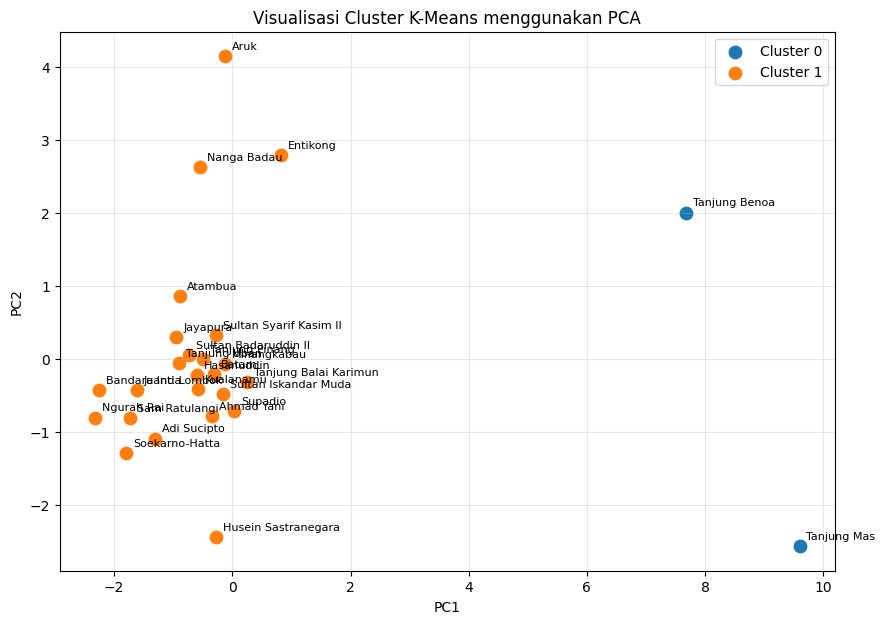

In [166]:
# Visualisasi Cluster dengan PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "Pintu Masuk": cluster_features.index,
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": labels_kmeans
})

print(
    "Explained variance ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

display(pca_df)

plt.figure(figsize=(10, 7))

for cluster in sorted(pca_df["Cluster"].unique()):
    data = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=f"Cluster {cluster}",
        s=80
    )

    for _, row in data.iterrows():
        plt.annotate(
            row["Pintu Masuk"],
            (row["PC1"], row["PC2"]),
            fontsize=8,
            xytext=(5, 5),
            textcoords="offset points"
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualisasi Cluster K-Means menggunakan PCA")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [167]:
# FINAL FITTING MODEL K-MEANS
from sklearn.cluster import KMeans

final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(X_scaled)

print("Model K-Means final berhasil di-fit.")
print("\nDistribusi cluster:")
print(
    pd.Series(final_labels)
    .value_counts()
    .sort_index()
)

Model K-Means final berhasil di-fit.

Distribusi cluster:
0     2
1    24
Name: count, dtype: int64


In [168]:
# HASIL 
final_cluster_result = pd.DataFrame({
    "Pintu Masuk": cluster_features.index,
    "Cluster": final_labels
})

display(
    final_cluster_result
    .sort_values(["Cluster", "Pintu Masuk"])
)

,Pintu Masuk,Cluster
22,Tanjung Benoa,0
23,Tanjung Mas,0
0,Adi Sucipto,1
1,Ahmad Yani,1
2,Aruk,1
3,Atambua,1
4,Bandara Int. Lombok,1
5,Batam,1
6,Entikong,1
7,Hasanuddin,1


In [169]:
# EVAL FINAL

final_silhouette = silhouette_score(
    X_scaled,
    final_labels
)

final_dbi = davies_bouldin_score(
    X_scaled,
    final_labels
)

final_ch = calinski_harabasz_score(
    X_scaled,
    final_labels
)

print("Evaluasi Model K-Means Final")
print(f"Silhouette          : {final_silhouette:.4f}")
print(f"Davies-Bouldin      : {final_dbi:.4f}")
print(f"Calinski-Harabasz   : {final_ch:.4f}")

Evaluasi Model K-Means Final
Silhouette          : 0.6295
Davies-Bouldin      : 0.7270
Calinski-Harabasz   : 19.5933


# SAVE MODEL

In [172]:
import os
import joblib

# Buat folder model jika belum ada
os.makedirs("model", exist_ok=True)

# Simpan model K-Means final
joblib.dump(
    final_kmeans,
    "model/kmeans_clustering_final.pkl"
)

# Simpan scaler yang digunakan saat training
joblib.dump(
    scaler,
    "model/scaler_clustering.pkl"
)

print("Model dan scaler berhasil disimpan:")
print("- model/kmeans_clustering_final.pkl")
print("- model/scaler_clustering.pkl")

Model dan scaler berhasil disimpan:
- model/kmeans_clustering_final.pkl
- model/scaler_clustering.pkl
